In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("data.csv")

In [3]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
new_df = df[[
    "price",
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "city"
]]

In [5]:
new_df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,sqft_above,sqft_basement,yr_built,city
0,313000.0,3.0,1.50,1340,7912,1.5,0,3,1340,0,1955,Shoreline
1,2384000.0,5.0,2.50,3650,9050,2.0,4,5,3370,280,1921,Seattle
2,342000.0,3.0,2.00,1930,11947,1.0,0,4,1930,0,1966,Kent
3,420000.0,3.0,2.25,2000,8030,1.0,0,4,1000,1000,1963,Bellevue
4,550000.0,4.0,2.50,1940,10500,1.0,0,4,1140,800,1976,Redmond


In [18]:
avg_houseprice=new_df.groupby("city")["price"].mean().round(2)
avg_houseprice


city
Algona                  207288.00
Auburn                  299340.44
Beaux Arts Village      745000.00
Bellevue                847180.66
Black Diamond           339605.56
Bothell                 481441.89
Burien                  348947.25
Carnation               508751.95
Clyde Hill             1321945.45
Covington               296230.40
Des Moines              304992.55
Duvall                  403994.13
Enumclaw                307614.58
Fall City               692681.82
Federal Way             289887.70
Inglewood-Finn Hill     425000.00
Issaquah                596163.75
Kenmore                 447494.04
Kent                    439492.44
Kirkland                651583.59
Lake Forest Park        448475.00
Maple Valley            336474.91
Medina                 2046559.09
Mercer Island          1123817.62
Milton                  285000.00
Newcastle               666046.70
Normandy Park           506793.06
North Bend              399565.71
Pacific                 225233.33
Preston  

In [16]:
print(avg_houseprice.idxmax())
print(avg_houseprice.max())

Medina
2046559.09


Text(0.5, 1.0, 'sqft_living vs Price')

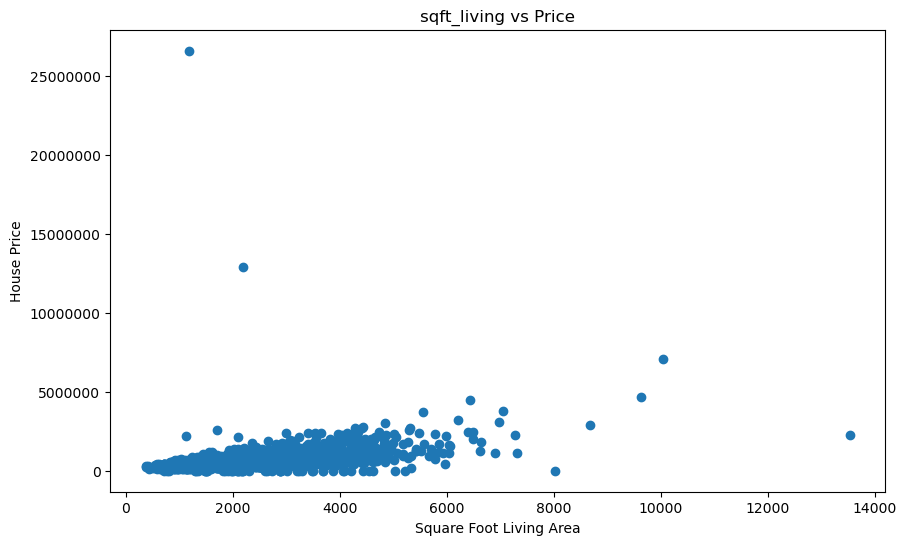

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(new_df["sqft_living"],new_df["price"])
plt.xlabel("Square Foot Living Area")
plt.ylabel("House Price")
plt.ticklabel_format(style='plain', axis='y')
plt.title("sqft_living vs Price")

In [24]:
corr = new_df.corr(numeric_only=True)

print(corr["price"].sort_values(ascending=False))

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
Name: price, dtype: float64


In [37]:
import numpy as np


new_df["year_cat"] = pd.cut(
    new_df["yr_built"],
    bins=[0,1950,1970,1990,2010,np.inf],
    labels=[1,2,3,4,5]
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24312\4021196922.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["year_cat"] = pd.cut(


In [38]:
new_df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,sqft_above,sqft_basement,yr_built,city,year_cat
0,3.130000e+05,3.0,1.50,1340,7912,1.5,0,3,1340,0,1955,Shoreline,2
1,2.384000e+06,5.0,2.50,3650,9050,2.0,4,5,3370,280,1921,Seattle,1
2,3.420000e+05,3.0,2.00,1930,11947,1.0,0,4,1930,0,1966,Kent,2
3,4.200000e+05,3.0,2.25,2000,8030,1.0,0,4,1000,1000,1963,Bellevue,2
4,5.500000e+05,4.0,2.50,1940,10500,1.0,0,4,1140,800,1976,Redmond,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3.0,1.75,1510,6360,1.0,0,4,1510,0,1954,Seattle,2
4596,5.343333e+05,3.0,2.50,1460,7573,2.0,0,3,1460,0,1983,Bellevue,3
4597,4.169042e+05,3.0,2.50,3010,7014,2.0,0,3,3010,0,2009,Renton,4
4598,2.034000e+05,4.0,2.00,2090,6630,1.0,0,3,1070,1020,1974,Seattle,3


In [40]:
new_df.to_csv("clean_house_data.csv", index=False)